# Sonuçlar: Test Seti Performansı

`models/best_model.pt` (en iyi validation loss'ta kaydedilen LSTM modeli) `scripts/evaluate.py` ile test setinde değerlendirilir. Ölçeklenmiş tahminler `MinMaxScaler.inverse_transform` ile gerçek fiyat birimine çevrilir; sonuçlar RMSE, MAE ve MAPE metrikleriyle ve gerçek/tahmin fiyat grafiğiyle özetlenir.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

SCRIPTS_DIR = Path.cwd().resolve().parent / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))

from evaluate import RESULTS_DIR, plot_predictions_vs_actual, run_evaluation

results = run_evaluation()

## Metrikler

In [2]:
metrics_df = pd.DataFrame(
    [{"RMSE": results["rmse"], "MAE": results["mae"], "MAPE (%)": results["mape"]}]
)
metrics_df

,RMSE,MAE,MAPE (%)
0,9.266602,7.034477,2.288572


## Gerçek vs. Tahmin Edilen Fiyat

Grafik `results/predictions_vs_actual.png` olarak da kaydedilir.

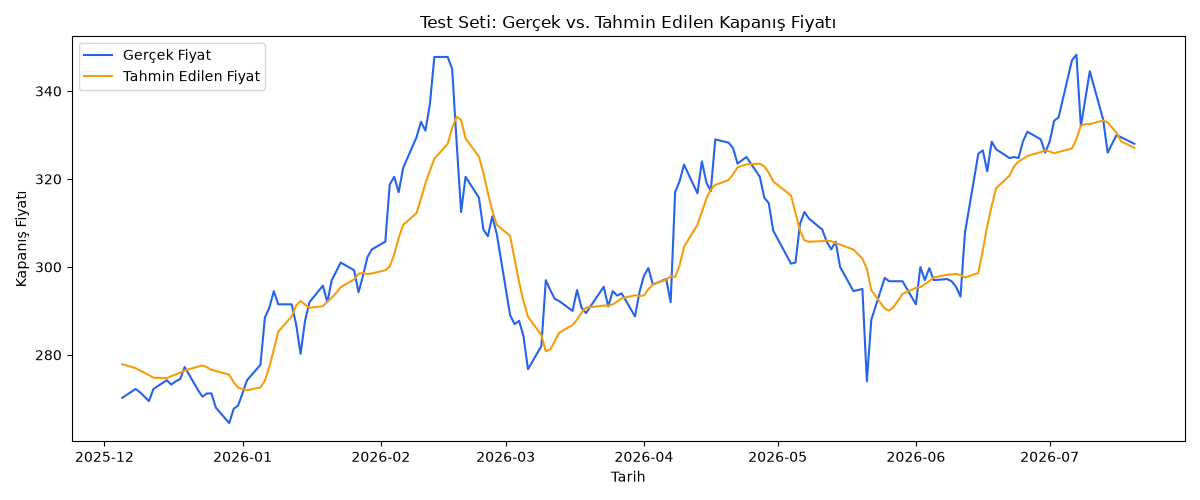

In [3]:
plot_path = RESULTS_DIR / "predictions_vs_actual.png"
plot_predictions_vs_actual(results["dates"], results["actuals"], results["preds"], plot_path)
display(Image(filename=str(plot_path)))